# **1. Project Setup**


## **1.1 Import Libraries**
These libraries will be used throughout the project for cleaning the dataset, analyzing customer behaviour, building segmentation models, and evaluating prediction performance.

In [1]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

import joblib
import os

import pickle
import warnings
warnings.filterwarnings("ignore")

## 1.1 Load the Dataset
The dataset `data.csv` is loaded into a pandas DataFrame. This provides access to the transaction records and allows the data to be explored and processed efficiently.

In [2]:
df = pd.read_csv("data.csv", encoding="ISO-8859-1")

## 1.2 Display the First Rows

The first few rows of the dataset are displayed to gain an initial understanding of the structure of the data, the column names, and the type of information recorded in each row.


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## 1.3 Check the Dataset Shape
The shape of the dataset is examined to identify the total number of rows and columns. This helps in understanding the size of the dataset before cleaning and transformation.


In [4]:
df.shape

(541909, 8)

## 1.4 Check Columns and Data Types
The column names and data types are inspected to understand the structure of the dataset. This step is important for identifying categorical and numerical variables, checking whether date fields need conversion, and detecting potential data quality issues before further analysis.

In [5]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


# **2. Initial Data Understanding**

Before cleaning the dataset, it is important to inspect the data quality.  
This step helps identify missing values, duplicate records, cancelled invoices, invalid quantities or prices, and unusual product codes that may affect analysis.

In [8]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


## 2.1 Duplicate Rows

Duplicate rows may occur due to data entry errors or system issues.  
These duplicates can distort transaction counts and revenue calculations, so it is important to identify them before cleaning the dataset.

In [9]:
df.duplicated().sum()

np.int64(5268)

## 2.2 Cancelled Invoices

In this dataset, cancelled transactions are identified by invoice numbers that start with the letter **"C"**.  
These usually represent returned items or cancelled purchases.  
Examining these records helps determine how return transactions should be handled during analysis.

In [10]:
df[df["InvoiceNo"].astype(str).str.startswith("C")].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [11]:
df["InvoiceNo"].astype(str).str.startswith("C").sum()

np.int64(9288)

## 2.3 Invalid Quantity Values

Negative quantities typically indicate returned items.  
These records are examined to understand how often product returns occur and how they should be treated during data preprocessing.

In [12]:
df[df["Quantity"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [13]:
(df["Quantity"] <= 0).sum()

np.int64(10624)

## 2.4 Invalid Unit Price Values

Unit price values should normally be positive.  
Negative or zero prices may indicate data entry errors, discounts, or system adjustments.  
These values are inspected to determine whether they should be corrected or removed.

In [14]:
df[df["UnitPrice"] <= 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,12/1/2010 14:32,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,12/1/2010 14:33,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,12/1/2010 14:34,0.0,NaN,United Kingdom


In [15]:
(df["UnitPrice"] <= 0).sum()

np.int64(2517)

## 2.5 Most Frequent Stock Codes

To better understand the dataset, the most frequently occurring stock codes are examined.  
This helps identify the products that appear most often in transactions and provides insight into commonly purchased items.


In [16]:
df["StockCode"].value_counts().head(20)

,count
StockCode,
85123A,2313
22423,2203
85099B,2159
47566,1727
20725,1639
84879,1502
22720,1477
22197,1476
21212,1385


## 2.7 Inspect Special or Non-Product Stock Codes

The `StockCode` column primarily represents product identifiers. However, some codes may represent operational transactions such as shipping charges, discounts, or manual adjustments rather than actual products.

Instead of only looking at the most frequent codes, the dataset is inspected to identify stock codes that contain alphabetic characters or special labels that may indicate non-product entries.

In [17]:
# Find stock codes that contain letters
df[df["StockCode"].str.isalpha()]["StockCode"].value_counts()

,count
StockCode,
POST,1256
DOT,710
M,571
D,77
S,63
AMAZONFEE,34
CRUK,16
DCGSSGIRL,13
DCGSSBOY,11


The results show several codes such as POST, DOT, M, and D. These entries are not product identifiers but operational transaction types.

For example:
- POST typically represents postage or shipping charges
- D represents a discount applied to a transaction
- M may indicates manual adjustments
- DOT may represent system adjustments

These codes will be handled appropriately during the data cleaning stage depending on whether they provide useful analytical insights.

# **3. Data Cleaning**

After exploring the dataset and identifying potential data quality issues, the next step is to clean the dataset before performing feature engineering and modelling.

The main objectives of this stage are:

- remove duplicate records
- handle missing customer identifiers
- handle returned transactions
- remove operational stock codes that do not represent real products
- create useful features for later analysis

Cleaning the dataset ensures that the subsequent analysis reflects accurate customer purchasing behaviour.

## 3.1 Remove Duplicate Rows

Duplicate rows may occur due to system errors or repeated records.  
Removing duplicate transactions helps prevent incorrect calculations for sales, revenue, and customer purchasing behaviour.

In [18]:
# remove duplicate rows
df = df.drop_duplicates()

# check remaining duplicates
df.duplicated().sum()

np.int64(0)

## 3.2 Handle Missing CustomerID

Customer segmentation requires valid customer identifiers.  
Transactions without a `CustomerID` cannot be associated with a specific customer and therefore cannot be used for customer-level analysis.

Rows with missing `CustomerID` values are removed from the dataset.

In [19]:
# remove rows without customer ID
df = df.dropna(subset=["CustomerID"])

# convert customer ID to integer
df["CustomerID"] = df["CustomerID"].astype(int)

## 3.3 Classify Transaction Type
Transactions in the dataset can represent different types of events such as product purchases, discounts, or returned items.

To capture this information, a new column called **TransactionType** is created.

Transactions are classified into three categories:

- **Complete** – normal product purchase
- **Return** – returned products (cancelled invoice)
- **Discount** – transactions identified by StockCode `D`

In [20]:
df["TransactionType"] = "Complete"

# mark returns using invoice prefix
df.loc[df["InvoiceNo"].astype(str).str.startswith("C"), "TransactionType"] = "Return"

# mark discounts
df.loc[df["StockCode"] == "D", "TransactionType"] = "Discount"

df["TransactionType"].value_counts()

,count
TransactionType,
Complete,392732
Return,8795
Discount,77


## 3.4 Remove Operational Stock Codes

Some stock codes represent operational transactions such as postage charges, adjustments, commissions, or system records rather than actual product purchases.

These codes are removed so that the dataset focuses only on real customer transactions.

In [21]:
remove_codes = [
    "POST","DOT","M","S","CRUK",
    "B","m"
]

df = df[~df["StockCode"].isin(remove_codes)]

## 3.5 Remove Invalid Prices

Unit prices should normally be positive values.  
Rows containing zero or negative prices may represent data errors or system adjustments, so they are removed.

In [22]:
df = df[df["UnitPrice"] > 0]

## 3.6 Create Transaction Value (TotalPrice)

A new feature called **TotalPrice** is created to represent the total value of each transaction.

TotalPrice is calculated as:

TotalPrice = Quantity × UnitPrice

This feature will later be used to calculate the **Monetary** component of RFM analysis.

In [23]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom,Complete,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom,Complete,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom,Complete,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom,Complete,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom,Complete,20.34


## 3.7 Convert InvoiceDate to Datetime FormaFormat

The `InvoiceDate` column is converted to datetime format to allow time-based analysis such as calculating recency and analysing sales trends over time.

In [24]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

## 3.8 Remove Customers With Only Return Transactions

Some customers in the dataset appear only with cancelled transactions (credit notes) and have no completed purchases. These customers do not represent meaningful purchasing behavior and may distort customer segmentation results.

Therefore, customers with only return transactions are removed from the dataset before performing RFM analysis.


In [25]:
returns_only = df.groupby("CustomerID")["TransactionType"].unique()

returns_only[returns_only.apply(lambda x: "Complete" not in x)]

,TransactionType
CustomerID,
12605,[Return]
12666,[Return]
12870,[Return]
12943,[Return]
13693,[Return]
13829,[Return]
13958,[Return]
14119,[Return]
14213,[Return]


In [26]:
# identify customers with at least one completed purchase
valid_customers = df[df["TransactionType"] == "Complete"]["CustomerID"].unique()

# keep only valid customers
df = df[df["CustomerID"].isin(valid_customers)]

# check remaining customers
df["CustomerID"].nunique()


4335

## 3.9 Verify Cleaned Dataset

Finally, the dataset is inspected again to confirm that invalid records have been removed and that the dataset is ready for further analysis.

In [27]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 399798 entries, 0 to 541908
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   InvoiceNo        399798 non-null  object        
 1   StockCode        399798 non-null  object        
 2   Description      399798 non-null  object        
 3   Quantity         399798 non-null  int64         
 4   InvoiceDate      399798 non-null  datetime64[ns]
 5   UnitPrice        399798 non-null  float64       
 6   CustomerID       399798 non-null  int64         
 7   Country          399798 non-null  object        
 8   TransactionType  399798 non-null  object        
 9   TotalPrice       399798 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 33.6+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,399798.000000,399798,399798.000000,399798.000000,399798.000000
mean,12.191362,2011-07-10 13:23:35.709633792,2.936920,15288.409019,20.684678
min,-80995.000000,2010-12-01 08:26:00,0.001000,12346.000000,-168469.600000
25%,2.000000,2011-04-06 15:47:00,1.250000,13959.000000,4.250000
50%,5.000000,2011-07-29 16:24:00,1.950000,15150.000000,11.590000
75%,12.000000,2011-10-20 12:03:00,3.750000,16791.000000,19.500000
max,80995.000000,2011-12-09 12:50:00,1867.860000,18287.000000,168469.600000
std,250.020650,NaN,5.537396,1710.531894,425.468349


In [28]:
df.to_csv("cleaned_data.csv", index=False)

# 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is conducted to understand customer purchasing behaviour and identify important patterns in the dataset.

This step helps uncover insights about sales performance, product demand, customer activity, and transaction patterns before building machine learning models.

The analysis focuses on:

- sales distribution across countries
- top selling products
- sales trends over time
- customer purchasing behaviour
- distribution of transaction types

## 4.1 Sales by Country

This analysis examines how sales are distributed across different countries.  
Understanding geographic sales distribution helps identify the most important markets for the business.

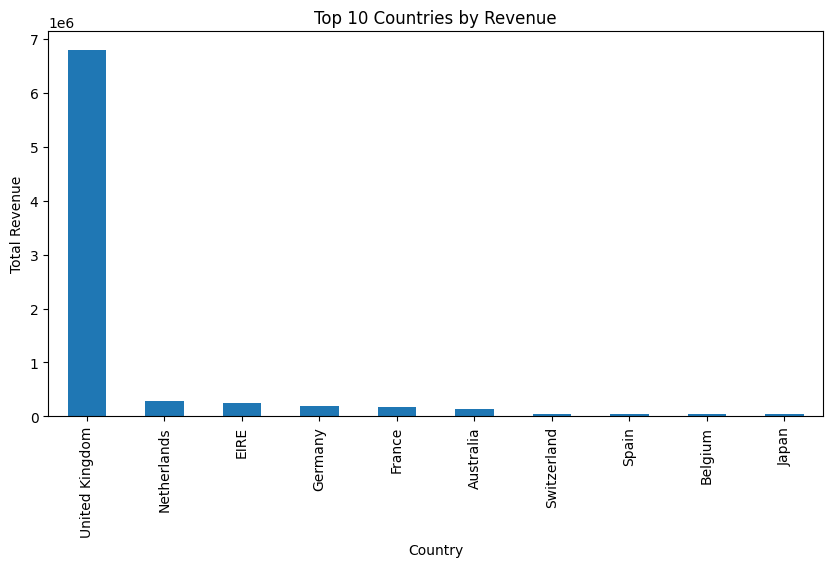

In [29]:
country_sales = df.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_sales.head(10).plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.show()

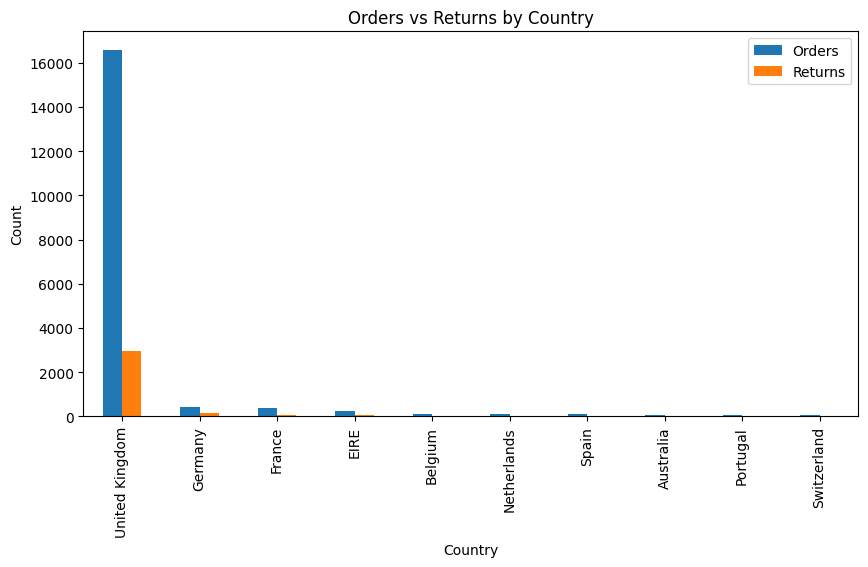

In [30]:
# completed orders
df_complete = df[df["TransactionType"] == "Complete"]
orders_by_country = df_complete.groupby("Country")["InvoiceNo"].nunique()

# returns
df_return = df[df["TransactionType"] == "Return"]
returns_by_country = df_return.groupby("Country")["InvoiceNo"].nunique()

# combine results
country_comparison = pd.concat([orders_by_country, returns_by_country], axis=1)
country_comparison.columns = ["Orders", "Returns"]

# sort by orders
country_comparison = country_comparison.sort_values("Orders", ascending=False)

# plot
country_comparison.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Orders vs Returns by Country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.xticks(rotation=90)

plt.show()

## 4.2 Top Selling Products

This analysis identifies the most frequently purchased products in the dataset.  
Understanding product popularity helps businesses optimize inventory and marketing strategies.

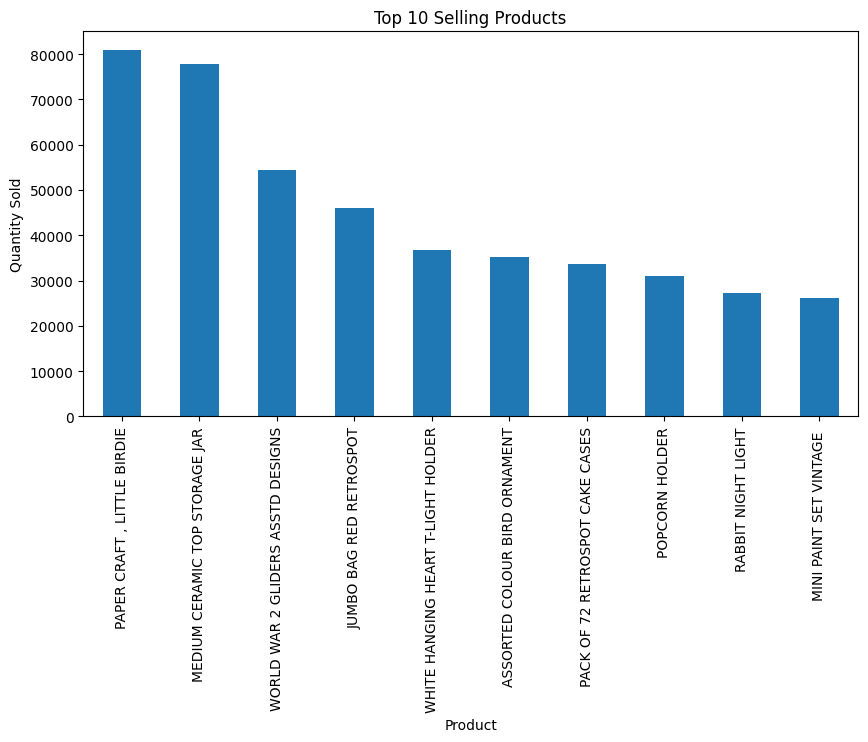

In [31]:
# filter completed transactions
df_complete = df[df["TransactionType"] == "Complete"]

# calculate quantity sold per product
top_products = df_complete.groupby("Description")["Quantity"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

top_products.head(10).plot(kind="bar")

plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

## **4.3 Returned Items Analysis**

Returned items represent products that customers sent back after purchase.
Analyzing returned transactions helps identify potential issues such as product dissatisfaction, quality problems, or inaccurate product descriptions.

In this step, returned transactions are examined to understand the most frequently returned products.

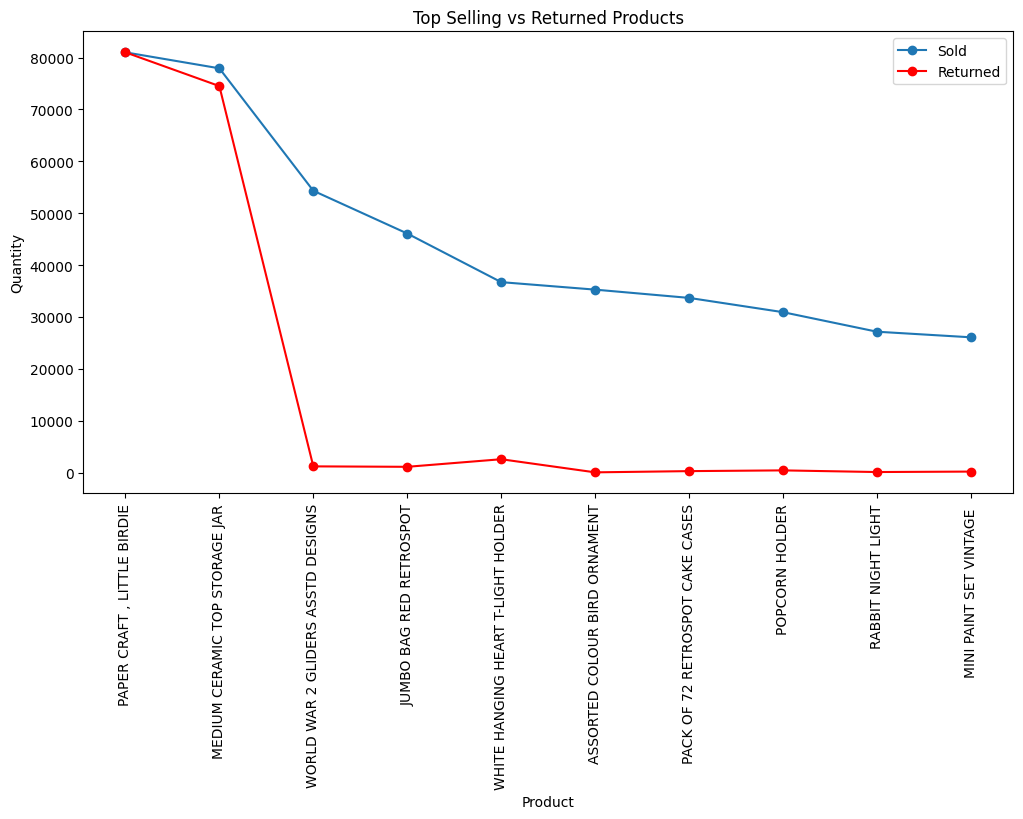

In [32]:
# filter transactions
df_complete = df[df["TransactionType"] == "Complete"]
df_return = df[df["TransactionType"] == "Return"]

# calculate quantities
top_sales = df_complete.groupby("Description")["Quantity"].sum()
top_returns = df_return.groupby("Description")["Quantity"].sum().abs()

# combine both datasets
product_compare = pd.concat([top_sales, top_returns], axis=1)
product_compare.columns = ["Sold", "Returned"]

# sort by sales
product_compare = product_compare.sort_values("Sold", ascending=False)

# select top 10 products
top_products = product_compare.head(10)

# plot
plt.figure(figsize=(12,6))

plt.plot(top_products.index, top_products["Sold"], marker='o', label="Sold")
plt.plot(top_products.index, top_products["Returned"], marker='o', label="Returned", color="red")

plt.title("Top Selling vs Returned Products")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.xticks(rotation=90)

plt.legend()
plt.show()

## 4.4 Monthly Sales Trend

Sales trends over time are analyzed to understand seasonal patterns and changes in purchasing behaviour.

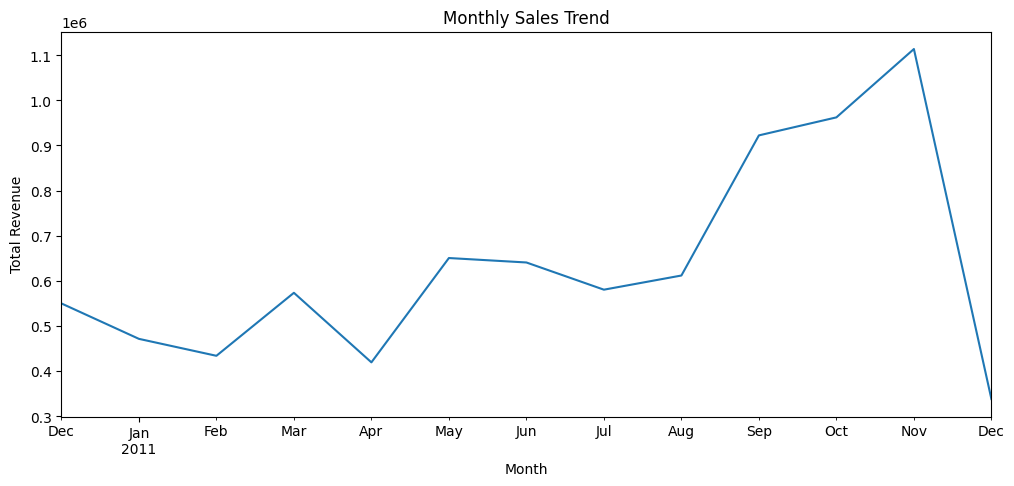

In [33]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = df.groupby("YearMonth")["TotalPrice"].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

## 4.5 Customer Purchase Distribution

This analysis examines how frequently customers make purchases.  
Understanding purchase frequency helps identify loyal customers and occasional buyers.

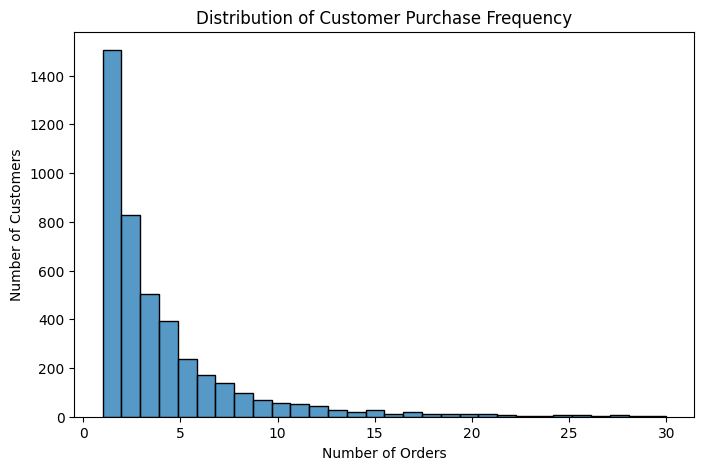

In [34]:
df_complete = df[df["TransactionType"] == "Complete"]

customer_orders = df_complete.groupby("CustomerID")["InvoiceNo"].nunique()

plt.figure(figsize=(8,5))

sns.histplot(customer_orders[customer_orders <= 30], bins=30)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.show()

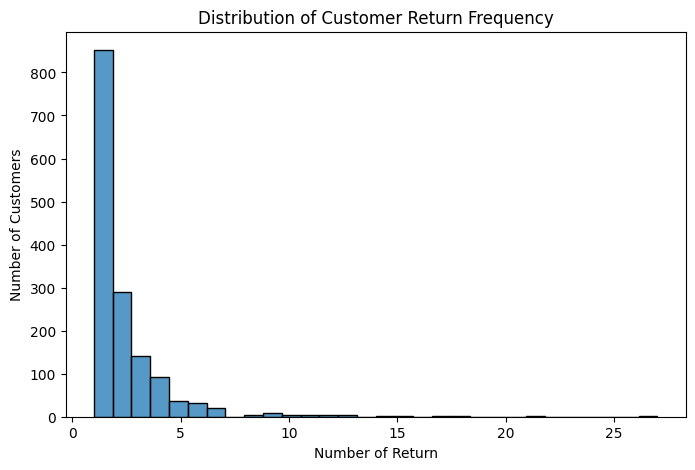

In [35]:
df_complete = df[df["TransactionType"] == "Return"]

customer_orders = df_complete.groupby("CustomerID")["InvoiceNo"].nunique()

plt.figure(figsize=(8,5))

sns.histplot(customer_orders[customer_orders <= 30], bins=30)

plt.title("Distribution of Customer Return Frequency")
plt.xlabel("Number of Return")
plt.ylabel("Number of Customers")

plt.show()

## 4.6 Transaction Type Distribution

This analysis shows the proportion of complete purchases, returns, and discount transactions in the dataset.  
Understanding transaction types provides insight into return behaviour and promotional activities.

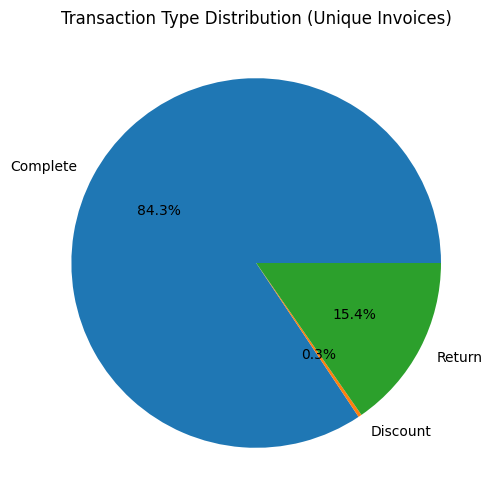

In [36]:
transaction_counts = df.groupby("TransactionType")["InvoiceNo"].nunique()

plt.figure(figsize=(6,6))

transaction_counts.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Transaction Type Distribution (Unique Invoices)")
plt.ylabel("")

plt.show()


## **Summary of Exploratory Analysis**

The exploratory analysis provides insights into customer purchasing behaviour and overall sales performance.

Key observations from this analysis will guide the feature engineering process and help design effective customer segmentation models.

# **5. Feature Engineering (RFM Analysis)**

To perform customer segmentation, the transaction-level dataset must be transformed into customer-level features. This is achieved using the RFM model.

RFM consists of three metrics:

- **Recency (R)** – how recently a customer made a purchase
- **Frequency (F)** – how often a customer makes purchases
- **Monetary (M)** – how much money the customer spends

In this dataset, return and discount transactions must be handled carefully to avoid bias.
Therefore, transaction classification is defined as:

- **Complete** – normal purchase transaction
- **Discount** – transactions with `StockCode = 'D'`
- **Return** – credit transactions that are not discounts


## 5.1 Reclassify Transaction Types Correctly




In [37]:
df["TransactionType"] = "Complete"

# classify discount first
df.loc[df["StockCode"] == "D", "TransactionType"] = "Discount"

# classify returns, excluding discounts
df.loc[
    (df["InvoiceNo"].astype(str).str.startswith("C")) &
    (df["StockCode"] != "D"),
    "TransactionType"
] = "Return"

df["TransactionType"].value_counts()


,count
TransactionType,
Complete,391298
Return,8423
Discount,77


## 5.2 Prepare Purchase Dataset

For RFM calculations:

- **Recency** and **Frequency** should be based only on completed purchase transactions
- **Monetary** should reflect net customer spending, including the effect of returns and discounts

A separate dataset containing only completed transactions is created for Recency and Frequency calculations.


In [38]:
df_complete = df[df["TransactionType"] == "Complete"].copy()

df_complete.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TransactionType,TotalPrice,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,Complete,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Complete,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,Complete,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Complete,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,Complete,20.34,2010-12


## 5.3 Define Reference Date

Recency measures the number of days since a customer's most recent purchase.

A reference date is defined as one day after the latest transaction date in the dataset. This ensures that all recency values are positive.


In [39]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date


Timestamp('2011-12-10 12:50:00')

## 5.4 Calculate Recency

Recency is calculated as the number of days between the reference date and the customer's last completed purchase date.


In [40]:
recency = df_complete.groupby("CustomerID")["InvoiceDate"].max()
recency = (snapshot_date - recency).dt.days


## 5.5 Calculate Frequency

Frequency represents how often a customer places orders.

This is calculated by counting the number of unique completed purchase invoices per customer.


In [41]:
frequency = df_complete.groupby("CustomerID")["InvoiceNo"].nunique()

## 5.6 Calculate Monetary Value

Monetary value represents the net amount spent by each customer.

This metric includes:

- positive spending from completed purchases
- negative values from returns
- negative values from discounts

This ensures that cancelled purchases and discounts reduce customer spending rather than inflating it.


In [42]:
monetary = df.groupby("CustomerID")["TotalPrice"].sum()

## 5.7 Create the RFM Table

The Recency, Frequency, and Monetary metrics are combined into a single customer-level dataset.

Each row represents one customer and summarizes their purchasing behaviour.


In [43]:
rfm = pd.concat([recency, frequency, monetary], axis=1)

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm = rfm.fillna(0)

rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,0.00
12347,2,7,4310.00
12348,75,4,1437.24
12349,19,1,1457.55
12350,310,1,294.40


## 5.8 Filter for Net Negative Customers

Some customers may have zero or negative monetary values because they returned more than they purchased.

These customers can distort segmentation results. Therefore, customers with non-positive monetary values may be removed before clustering.


In [44]:
rfm = rfm[rfm["Monetary"] > 0]

rfm.head()


,Recency,Frequency,Monetary
CustomerID,,,
12347,2,7,4310.00
12348,75,4,1437.24
12349,19,1,1457.55
12350,310,1,294.40
12352,36,7,1265.41


## 5.9 Inspect RFM Summary Statistics

Summary statistics are examined to understand the distribution of customer behaviour across the three RFM metrics.


In [45]:
rfm.describe()

,Recency,Frequency,Monetary
count,4325.000000,4325.000000,4.325000e+03
mean,92.469364,4.255260,1.912307e+03
std,100.047169,7.653429,8.310926e+03
min,1.000000,1.000000,1.776357e-15
25%,18.000000,1.000000,2.984000e+02
50%,51.000000,2.000000,6.484100e+02
75%,142.000000,5.000000,1.604440e+03
max,374.000000,206.000000,2.785716e+05


## 5.10 Visualize RFM Distributions

Histograms are used to inspect the distribution of Recency, Frequency, and Monetary values.

This helps identify skewness, variation, and potential outliers before clustering.


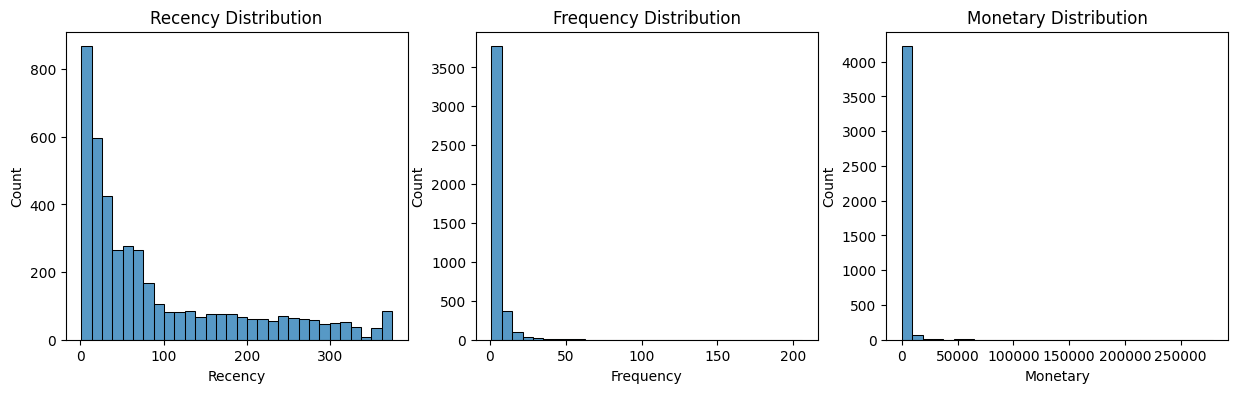

In [46]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(rfm["Recency"], bins=30)
plt.title("Recency Distribution")

plt.subplot(1,3,2)
sns.histplot(rfm["Frequency"], bins=30)
plt.title("Frequency Distribution")

plt.subplot(1,3,3)
sns.histplot(rfm["Monetary"], bins=30)
plt.title("Monetary Distribution")

plt.show()


## 5.11 Observations

The RFM table provides a compact representation of customer purchasing behaviour.

- Customers with **low Recency** purchased recently
- Customers with **high Frequency** place orders frequently
- Customers with **high Monetary** contribute more revenue

These features will be used in the next stage of the project to perform customer segmentation using clustering algorithms.


# **6. Outlier Detection and Treatment**

Before applying clustering algorithms, it is important to examine the RFM variables for extreme values. Outliers can significantly influence clustering results because algorithms such as K-Means rely on distance calculations.

The Interquartile Range (IQR) method is used to identify extreme values in the dataset. This method detects observations that fall far outside the normal distribution of the data.


## 6.1 Detect Outliers Using Boxplots

Boxplots provide a visual representation of the distribution of Recency, Frequency, and Monetary values and help identify extreme observations.


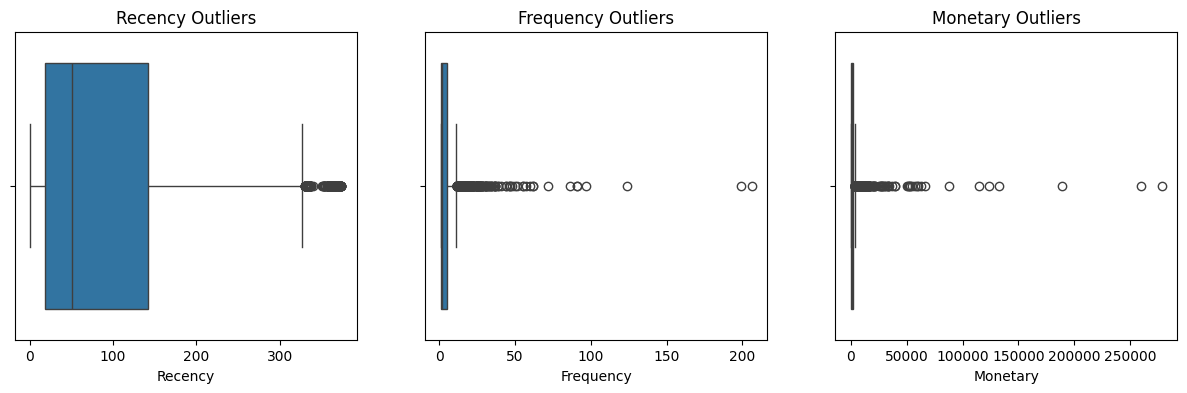

In [47]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.boxplot(x=rfm["Recency"])
plt.title("Recency Outliers")

plt.subplot(1,3,2)
sns.boxplot(x=rfm["Frequency"])
plt.title("Frequency Outliers")

plt.subplot(1,3,3)
sns.boxplot(x=rfm["Monetary"])
plt.title("Monetary Outliers")

plt.show()


## 6.2 Remove Extreme Outliers Using IQR Method

The Interquartile Range (IQR) method identifies values that lie outside the typical range of the data distribution.

Values outside the following range are considered outliers:

Lower Bound = Q1 − 1.5 × IQR  
Upper Bound = Q3 + 1.5 × IQR


In [48]:
Q1 = rfm.quantile(0.25)
Q3 = rfm.quantile(0.75)

IQR = Q3 - Q1

rfm_filtered = rfm[
    ~((rfm < (Q1 - 1.5 * IQR)) |
      (rfm > (Q3 + 1.5 * IQR))).any(axis=1)
]

rfm_filtered.shape


(3711, 3)

## 6.3 Inspect Cleaned Dataset

After removing extreme outliers, the dataset is re-examined to confirm the updated distribution of RFM values.


In [49]:
rfm_filtered.describe()


,Recency,Frequency,Monetary
count,3711.000000,3711.000000,3.711000e+03
mean,89.883320,2.838319,8.614771e+02
std,88.882903,2.196848,7.927054e+02
min,1.000000,1.000000,1.776357e-15
25%,22.000000,1.000000,2.870950e+02
50%,55.000000,2.000000,5.847500e+02
75%,139.000000,4.000000,1.198085e+03
max,327.000000,11.000000,3.560080e+03


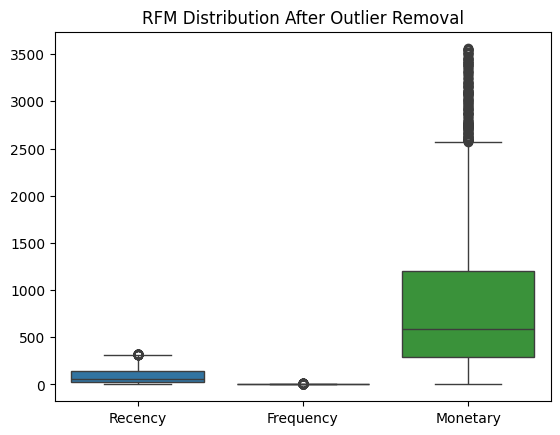

In [50]:
sns.boxplot(data=rfm_filtered)
plt.title("RFM Distribution After Outlier Removal")
plt.show()

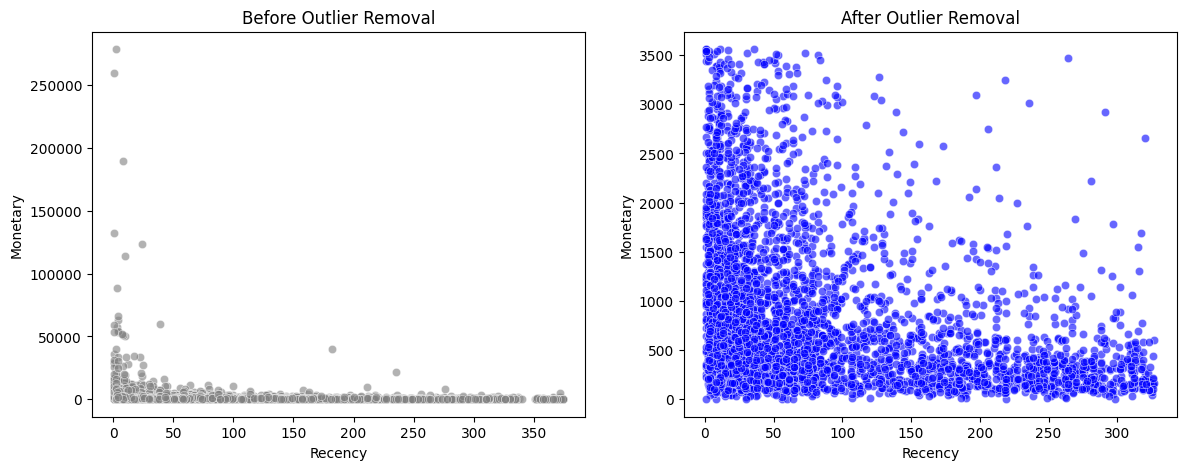

In [51]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

# before
sns.scatterplot(
    ax=axes[0],
    x=rfm["Recency"],
    y=rfm["Monetary"],
    color="gray",
    alpha=0.6
)

axes[0].set_title("Before Outlier Removal")
axes[0].set_xlabel("Recency")
axes[0].set_ylabel("Monetary")

# after
sns.scatterplot(
    ax=axes[1],
    x=rfm_filtered["Recency"],
    y=rfm_filtered["Monetary"],
    color="blue",
    alpha=0.6
)

axes[1].set_title("After Outlier Removal")
axes[1].set_xlabel("Recency")
axes[1].set_ylabel("Monetary")

plt.show()

# **7. Feature Scaling**

Before applying clustering algorithms, the RFM features must be scaled.

Clustering algorithms such as K-Means rely on distance calculations. If variables have different ranges, features with larger values can dominate the clustering process.

For example:
- Recency ranges from roughly 1–327
- Frequency ranges from 1–11
- Monetary ranges from 0–3560

To ensure fair contribution from all variables, the RFM features are standardized using the **StandardScaler** method.


## 7.1 Prepare the RFM Dataset

The cleaned RFM dataset obtained after outlier removal will be used as the input for scaling.


In [52]:
rfm_filtered.head()


,Recency,Frequency,Monetary
CustomerID,,,
12348,75,4,1437.24
12349,19,1,1457.55
12350,310,1,294.40
12352,36,7,1265.41
12353,204,1,89.00


## 7.2 Apply Standardization

StandardScaler standardizes features by removing the mean and scaling them to unit variance.

After scaling:
- Mean = 0
- Standard deviation = 1

This allows clustering algorithms to treat all features equally.


In [53]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_filtered)


## 7.3 Convert Scaled Data to DataFrame
The scaled values are converted back into a DataFrame so that they can be easily inspected and used for further analysis.


In [54]:
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=rfm_filtered.columns,
    index=rfm_filtered.index
)

rfm_scaled.head()


,Recency,Frequency,Monetary
CustomerID,,,
12348,-0.167471,0.528866,0.726424
12349,-0.797599,-0.836911,0.752049
12350,2.476813,-0.836911,-0.715466
12352,-0.606310,1.894642,0.509631
12353,1.284072,-0.836911,-0.974613


## 7.4 Inspect Scaled Feature Statistics

After scaling, the features should have similar distributions centered around zero.


In [55]:
rfm_scaled.describe()


,Recency,Frequency,Monetary
count,3.711000e+03,3.711000e+03,3.711000e+03
mean,3.637918e-17,4.116591e-17,-7.658774e-18
std,1.000135e+00,1.000135e+00,1.000135e+00
min,-1.000139e+00,-8.369108e-01,-1.086902e+00
25%,-7.638417e-01,-8.369108e-01,-7.246822e-01
50%,-3.925167e-01,-3.816519e-01,-3.491390e-01
75%,5.526743e-01,5.288658e-01,4.246890e-01
max,2.668102e+00,3.715678e+00,3.404754e+00


# **8. Determine Optimal Number of Clusters**

Before applying K-Means clustering, it is necessary to determine the appropriate number of clusters.

The Elbow Method is commonly used to identify the optimal number of clusters by analyzing the relationship between the number of clusters and the within-cluster sum of squares (inertia).

The point where the decrease in inertia slows down significantly represents the optimal number of clusters.


## 8.1 Compute Inertia for Different Cluster Values


In [56]:
inertia = []

K = range(1,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)


## 8.2 Plot the Elbow Curve


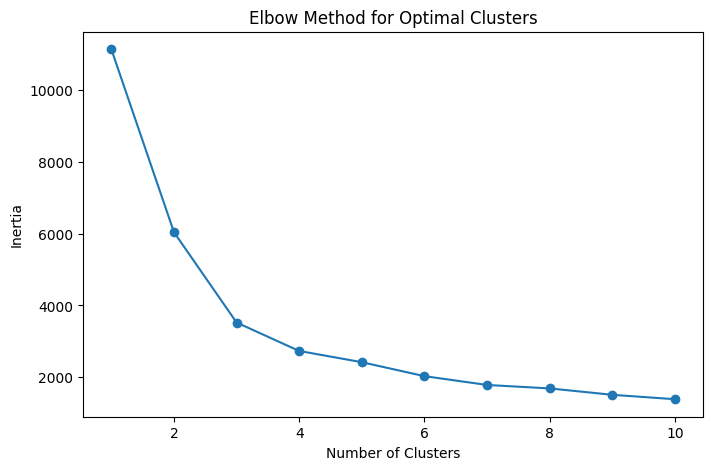

In [57]:
plt.figure(figsize=(8,5))

plt.plot(K, inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Clusters")

plt.show()


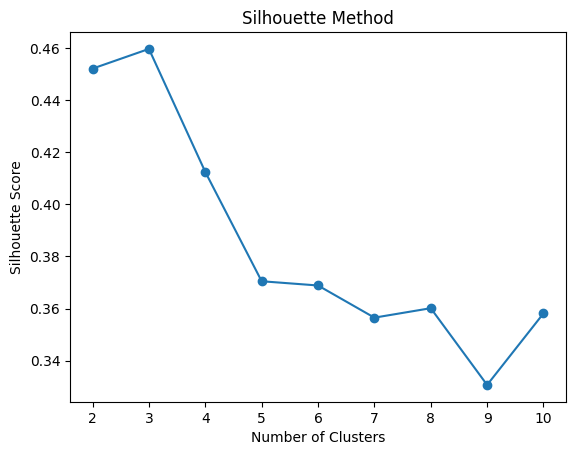

In [58]:
silhouette_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)

plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()


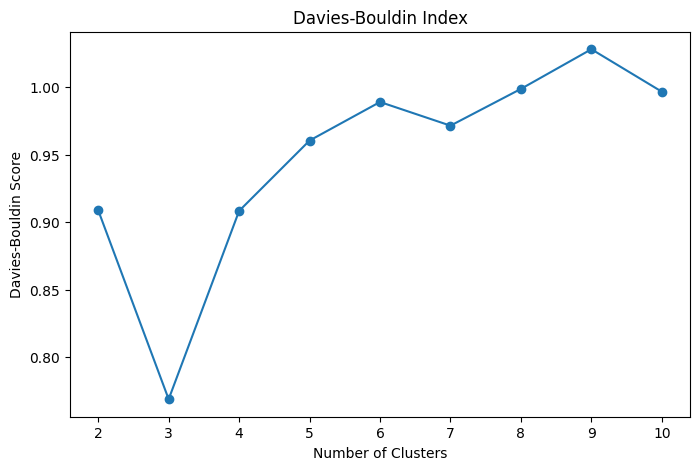

In [59]:
db_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = davies_bouldin_score(rfm_scaled, labels)
    db_scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), db_scores, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Score")
plt.title("Davies-Bouldin Index")

plt.show()


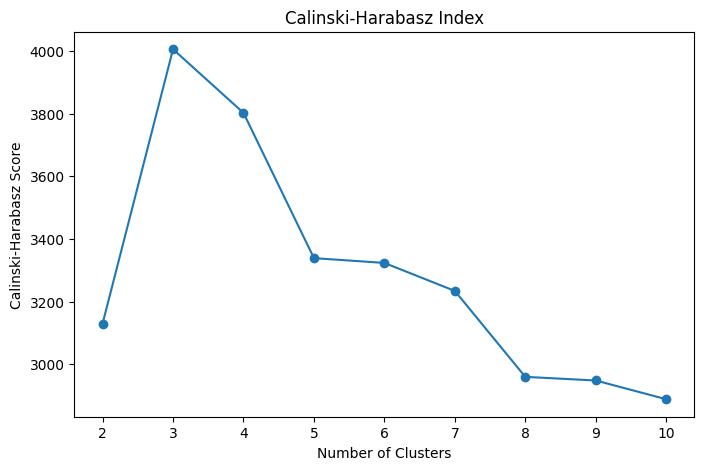

In [60]:
ch_scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = calinski_harabasz_score(rfm_scaled, labels)
    ch_scores.append(score)

plt.figure(figsize=(8,5))

plt.plot(range(2,11), ch_scores, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Calinski-Harabasz Score")
plt.title("Calinski-Harabasz Index")

plt.show()


## 8.3 Number of Clusters

Multiple evaluation metrics were used to determine the optimal number of clusters.

The Davies–Bouldin Index reached its lowest value at **k = 3**, indicating well-separated clusters.  
The Calinski–Harabasz Index reached its highest value at **k = 3**, suggesting strong cluster structure.

These results are consistent with the silhouette analysis, which also identified **k = 3** as the optimal number of clusters.

Therefore, the final clustering model uses **3 customer segments**.


# 9. K-Means Clustering

After determining the optimal number of clusters using multiple evaluation metrics, K-Means clustering is applied to segment customers based on their purchasing behavior.

K-Means groups customers by minimizing the distance between data points and cluster centers. The algorithm will divide customers into **three segments (k = 3)** based on the Recency, Frequency, and Monetary features.


## 9.1 Apply K-Means Clustering


In [61]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(rfm_scaled)

rfm_filtered["Cluster"] = clusters

rfm_filtered.head()


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12348,75,4,1437.24,1
12349,19,1,1457.55,0
12350,310,1,294.40,2
12352,36,7,1265.41,1
12353,204,1,89.00,2


## 9.2 Cluster Distribution

This section shows how many customers belong to each cluster.


In [62]:
rfm_filtered["Cluster"].value_counts()


,count
Cluster,
0,1966
2,911
1,834


## 9.3 Cluster Characteristics

To understand the behavior of each cluster, the average Recency, Frequency, and Monetary values are calculated.


In [63]:
cluster_summary = rfm_filtered.groupby("Cluster").mean()

cluster_summary


,Recency,Frequency,Monetary
Cluster,,,
0,48.969990,2.10885,575.224040
1,36.022782,6.02518,2035.740385
2,227.485181,1.49506,404.219122


## 9.4 Visualizing Customer Segments


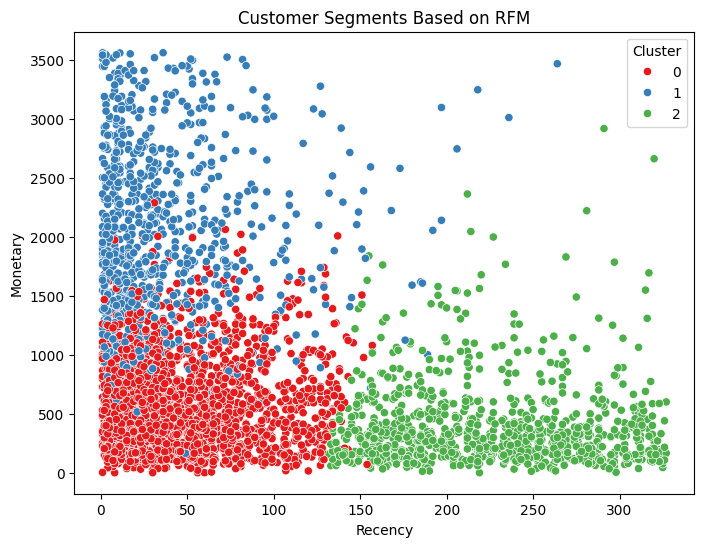

In [64]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=rfm_filtered["Recency"],
    y=rfm_filtered["Monetary"],
    hue=rfm_filtered["Cluster"],
    palette="Set1"
)

plt.title("Customer Segments Based on RFM")
plt.xlabel("Recency")
plt.ylabel("Monetary")

plt.show()


## 9.5 Customer Segments with Cluster Centers

This visualization shows customer segments based on Recency and Monetary values.
Cluster centers represent the average behavior of customers within each segment.

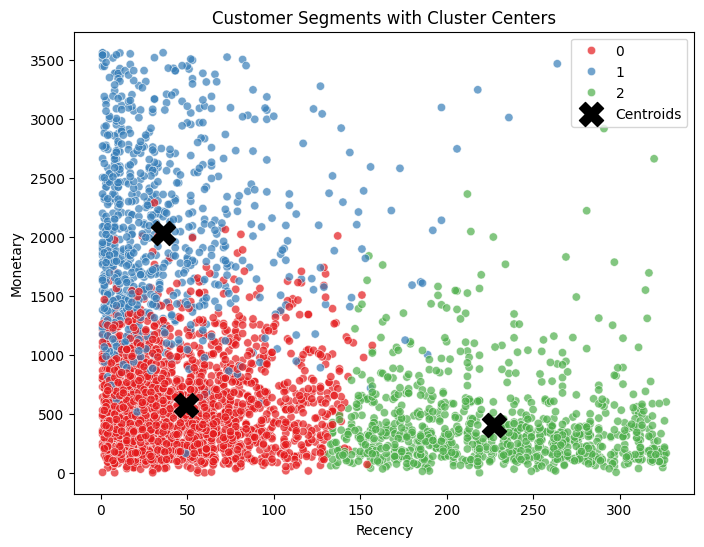

In [65]:
# get cluster centers
centers = kmeans.cluster_centers_

# convert centers back to original scale
centers_original = scaler.inverse_transform(centers)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=rfm_filtered["Recency"],
    y=rfm_filtered["Monetary"],
    hue=rfm_filtered["Cluster"],
    palette="Set1",
    alpha=0.7
)

# plot centroids
plt.scatter(
    centers_original[:,0],
    centers_original[:,2],
    c="black",
    s=300,
    marker="X",
    label="Centroids"
)

plt.title("Customer Segments with Cluster Centers")
plt.xlabel("Recency")
plt.ylabel("Monetary")

plt.legend()
plt.show()

## 9.6 Frequency vs Monetary Distribution of Customer Segments

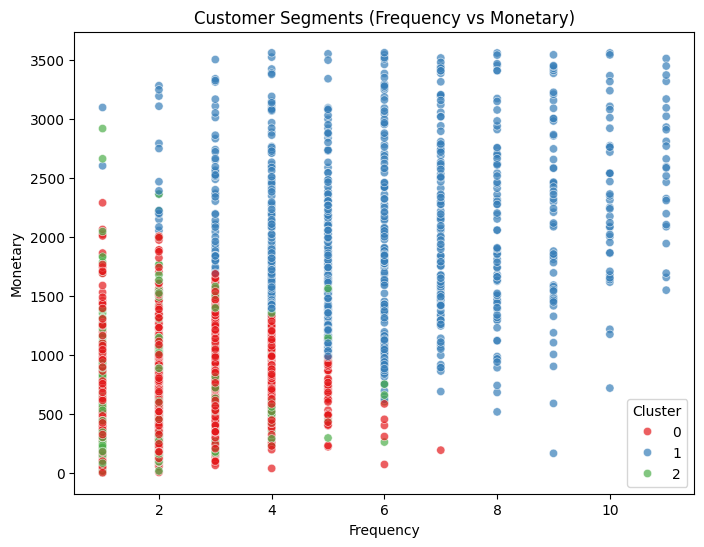

In [66]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=rfm_filtered["Frequency"],
    y=rfm_filtered["Monetary"],
    hue=rfm_filtered["Cluster"],
    palette="Set1",
    alpha=0.7
)

plt.title("Customer Segments (Frequency vs Monetary)")
plt.xlabel("Frequency")
plt.ylabel("Monetary")

plt.show()

## 9.7 Distribution of Customers Across Clusters

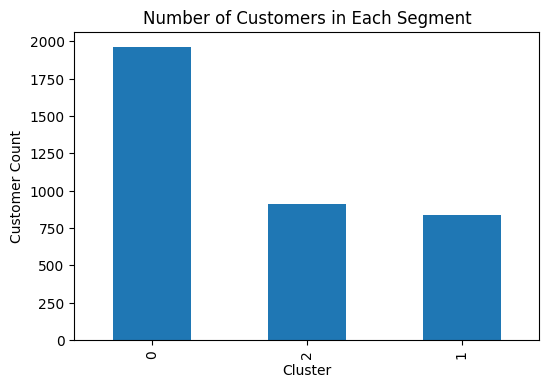

In [67]:
rfm_filtered["Cluster"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Number of Customers in Each Segment")
plt.xlabel("Cluster")
plt.ylabel("Customer Count")

plt.show()

# 10. Comparison of Clustering Algorithms

To evaluate the effectiveness of customer segmentation, multiple clustering algorithms were tested:

• K-Means Clustering  
• Hierarchical Clustering  
• DBSCAN Clustering  

These algorithms were compared using clustering evaluation metrics to determine which method produces the most meaningful customer segments.

## 10.1 Apply Hierarchical Clustering

In [68]:
hierarchical = AgglomerativeClustering(n_clusters=3)

rfm_filtered["HierarchicalCluster"] = hierarchical.fit_predict(rfm_scaled)

rfm_filtered.head()

,Recency,Frequency,Monetary,Cluster,HierarchicalCluster
CustomerID,,,,,
12348,75,4,1437.24,1,0
12349,19,1,1457.55,0,0
12350,310,1,294.40,2,1
12352,36,7,1265.41,1,0
12353,204,1,89.00,2,1


## 10.2 Apply DBSCAN Clustering

In [69]:
dbscan = DBSCAN(eps=0.8, min_samples=10)

rfm_filtered["DBSCANCluster"] = dbscan.fit_predict(rfm_scaled)

rfm_filtered.head()

,Recency,Frequency,Monetary,Cluster,HierarchicalCluster,DBSCANCluster
CustomerID,,,,,,
12348,75,4,1437.24,1,0,0
12349,19,1,1457.55,0,0,0
12350,310,1,294.40,2,1,0
12352,36,7,1265.41,1,0,0
12353,204,1,89.00,2,1,0


## 10.3 Evaluate Clustering Performance

Clustering performance is evaluated using:

• Silhouette Score  
• Davies–Bouldin Index  
• Calinski–Harabasz Index  

These metrics measure cluster separation and compactness.

In [70]:
# K-Means evaluation
kmeans_labels = rfm_filtered["Cluster"]

kmeans_silhouette = silhouette_score(rfm_scaled, kmeans_labels)
kmeans_db = davies_bouldin_score(rfm_scaled, kmeans_labels)
kmeans_ch = calinski_harabasz_score(rfm_scaled, kmeans_labels)

In [71]:
# Hierarchical evaluation
hier_labels = rfm_filtered["HierarchicalCluster"]

hier_silhouette = silhouette_score(rfm_scaled, hier_labels)
hier_db = davies_bouldin_score(rfm_scaled, hier_labels)
hier_ch = calinski_harabasz_score(rfm_scaled, hier_labels)

In [72]:
db_labels = rfm_filtered["DBSCANCluster"]

mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    db_silhouette = silhouette_score(rfm_scaled[mask], db_labels[mask])
    db_db = davies_bouldin_score(rfm_scaled[mask], db_labels[mask])
    db_ch = calinski_harabasz_score(rfm_scaled[mask], db_labels[mask])
else:
    db_silhouette = None
    db_db = None
    db_ch = None

## 10.4 Clustering Comparison Table

In [73]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "Hierarchical", "DBSCAN"],
    "Silhouette Score": [kmeans_silhouette, hier_silhouette, db_silhouette],
    "Davies-Bouldin Index": [kmeans_db, hier_db, db_db],
    "Calinski-Harabasz Index": [kmeans_ch, hier_ch, db_ch]
})

comparison

,Algorithm,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,0.459596,0.768812,4005.219623
1,Hierarchical,0.384198,0.797059,3133.887666
2,DBSCAN,NaN,NaN,NaN


# **11. Customer Segment Interpretation**

After applying K-Means clustering, customers were grouped into three segments based on their purchasing behavior.
To understand these segments, the average Recency, Frequency, and Monetary values are analyzed for each cluster.

In [74]:
cluster_profile = rfm_filtered.groupby("Cluster")[["Recency","Frequency","Monetary"]].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,48.969990,2.10885,575.224040
1,36.022782,6.02518,2035.740385
2,227.485181,1.49506,404.219122


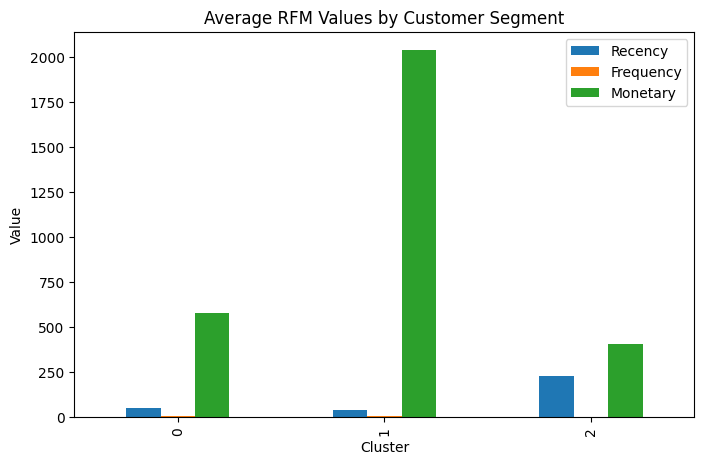

In [75]:
cluster_profile.plot(kind="bar", figsize=(8,5))

plt.title("Average RFM Values by Customer Segment")
plt.ylabel("Value")
plt.xlabel("Cluster")

plt.show()

# **12 Customer Segment + Future Purchase Prediction**

This section combines:

- Customer Segmentation Prediction (Cluster Assignment)
- Future Purchase Prediction

The user will enter a Customer ID once, and both predictions will be displayed.

## 12.1 Model Training

In [76]:
X = rfm_filtered[["Recency", "Frequency", "Monetary"]]
y = rfm_filtered["Cluster"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 12.2 Accuracy + Report

In [77]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9878869448183042

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.99      0.99       395
           1       0.97      1.00      0.98       169
           2       0.99      0.97      0.98       179

    accuracy                           0.99       743
   macro avg       0.98      0.99      0.99       743
weighted avg       0.99      0.99      0.99       743



## 12.3 Confusion Matrix Plot

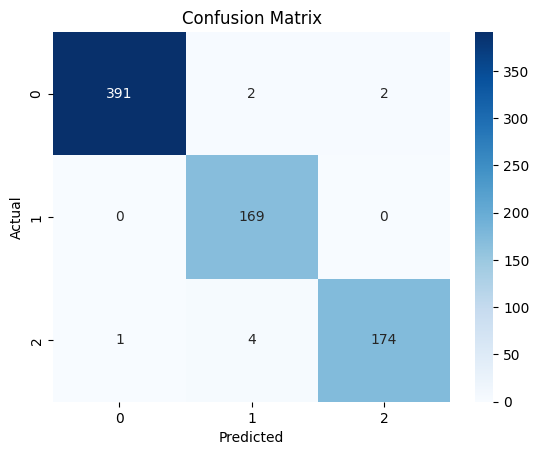

In [78]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 12.4 Feature Importance Plot

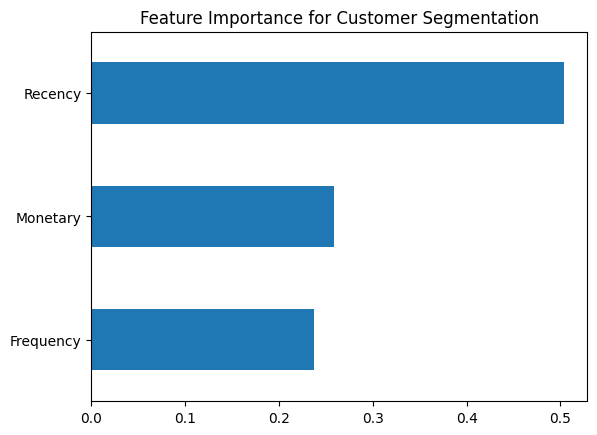

In [79]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance for Customer Segmentation")

plt.show()

## 12.5 Segment Prediction Function

In [80]:
def predict_customer_segment(customer_id, full_data, filtered_data, trained_model, segment_map=None):

    if customer_id not in full_data.index:
        print("Customer ID not found in the original dataset.")
        return

    if customer_id not in filtered_data.index:
        print("Customer ID exists in the original dataset but was removed during outlier filtering.")
        print("\nOriginal Customer Features:")
        display(full_data.loc[[customer_id], ["Recency", "Frequency", "Monetary"]])
        return

    customer_features = filtered_data.loc[[customer_id], ["Recency", "Frequency", "Monetary"]]

    predicted_cluster = trained_model.predict(customer_features)[0]

    if segment_map:
        predicted_name = segment_map.get(predicted_cluster, f"Cluster {predicted_cluster}")
    else:
        predicted_name = f"Cluster {predicted_cluster}"

    print(f"Customer ID: {customer_id}")
    print("\nCustomer Features:")
    display(customer_features)

    print(f"\nPredicted Cluster: {predicted_cluster}")
    print(f"Segment Name: {predicted_name}")

    if segment_map:
        if predicted_cluster == 1:
            print("Strategy: Focus on loyalty rewards and premium offers")
        elif predicted_cluster == 0:
            print("Strategy: Encourage more frequent purchases")
        elif predicted_cluster == 2:
            print("Strategy: Re-engagement campaigns")

In [81]:
segment_names = {
    0: "Regular Customers",
    1: "High-Value Customers",
    2: "Inactive Customers"
}

## 12.6 Future Purchase Prediction
Predicts whether a customer will purchase within the next 30 days.

In [82]:
df_purchase = df[df["TransactionType"] == "Complete"].copy()

df_purchase["InvoiceDate"] = pd.to_datetime(df_purchase["InvoiceDate"])

max_date = df_purchase["InvoiceDate"].max()
cutoff_date = max_date - pd.Timedelta(days=30)

history_data = df_purchase[df_purchase["InvoiceDate"] <= cutoff_date].copy()

future_data = df_purchase[
    (df_purchase["InvoiceDate"] > cutoff_date) &
    (df_purchase["InvoiceDate"] <= cutoff_date + pd.Timedelta(days=30))
].copy()

snapshot_date = cutoff_date + pd.Timedelta(days=1)

customer_features = history_data.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum",
    "Quantity": "sum"
})

customer_features.columns = ["Recency", "Frequency", "Monetary", "TotalItems"]

customer_features["AvgOrderValue"] = (
    customer_features["Monetary"] / customer_features["Frequency"]
)

future_customers = future_data["CustomerID"].unique()

customer_features["FuturePurchase"] = customer_features.index.isin(future_customers).astype(int)

## 12.7 Train/Test Split

In [83]:
X = customer_features[["Recency", "Frequency", "Monetary", "TotalItems", "AvgOrderValue"]]
y = customer_features["FuturePurchase"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 12.8 Baseline Model

In [84]:
baseline_model = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

baseline_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

## 12.9 Feature Importance Plot

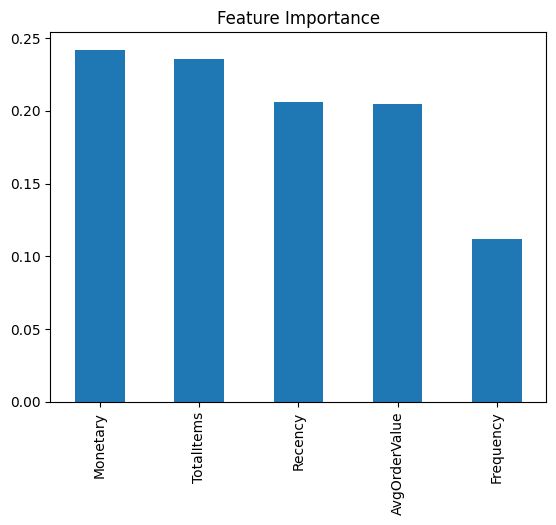

In [85]:
feature_importance = pd.Series(
    baseline_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

feature_importance.plot(kind="bar")

plt.title("Feature Importance")
plt.show()

## 12.10 Feature Selection

In [86]:
selected_features = feature_importance[feature_importance > 0.05].index.tolist()

X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

## 12.11 Hyperparameter Tuning

In [87]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_selected, y_train)

print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 200}


In [88]:
future_model = grid_search.best_estimator_

future_model.fit(X_train_selected, y_train)

y_pred = future_model.predict(X_test_selected)
purchase_prob = future_model.predict_proba(X_test_selected)[:, 1]

In [89]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7088452088452089
              precision    recall  f1-score   support

           0       0.79      0.76      0.78       538
           1       0.57      0.61      0.58       276

    accuracy                           0.71       814
   macro avg       0.68      0.68      0.68       814
weighted avg       0.71      0.71      0.71       814



## 12.12 Confusion Matrix

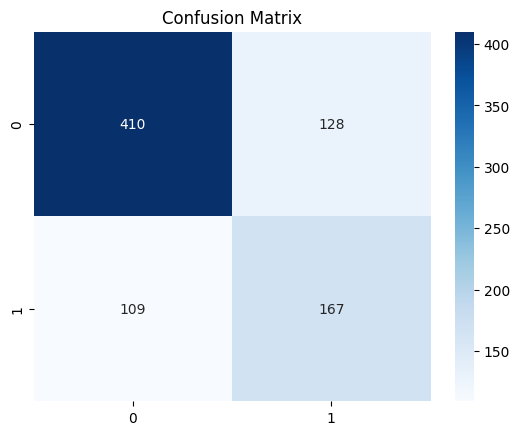

In [90]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

## 12.13 ROC Curve

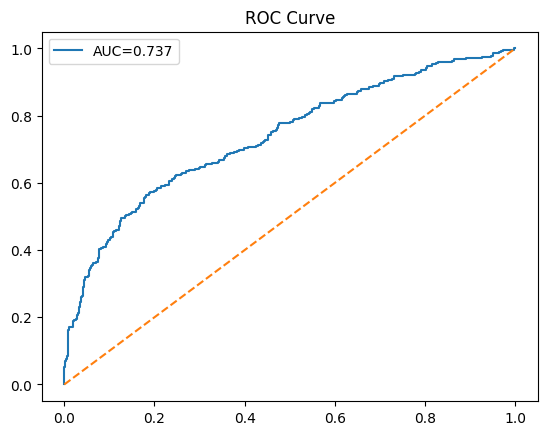

AUC: 0.7369080329723613


In [91]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, purchase_prob)
auc_score = roc_auc_score(y_test, purchase_prob)

plt.plot(fpr, tpr, label=f"AUC={auc_score:.3f}")
plt.plot([0,1],[0,1],"--")

plt.legend()
plt.title("ROC Curve")
plt.show()

print("AUC:", auc_score)

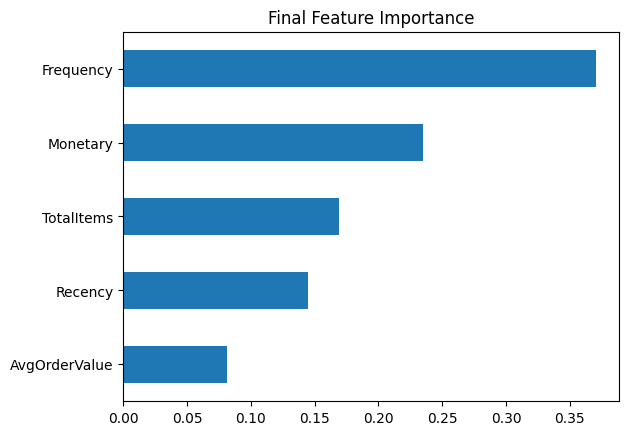

In [92]:
final_importance = pd.Series(
    future_model.feature_importances_,
    index=selected_features
)

final_importance.sort_values().plot(kind="barh")

plt.title("Final Feature Importance")
plt.show()

## 12.14 Prediction Function

In [93]:
def predict_future_purchase(customer_id):

    if customer_id not in customer_features.index:
        print("Customer not found")
        return

    row = customer_features.loc[[customer_id], selected_features]

    pred = future_model.predict(row)[0]
    prob = future_model.predict_proba(row)[0][1]

    print("Customer:", customer_id)
    display(row)

    print("Probability:", round(prob, 2))

    if pred == 1:
        print("Likely to purchase")
    else:
        print("Not likely to purchase")

## 12.15 Save Final Models

Save the final trained artifacts so they can be reused for deployment, reporting, and Streamlit integration.

In [94]:
# Create a folder to store the trained models
model_dir = "saved_models"
os.makedirs(model_dir, exist_ok=True)

# Save final models
joblib.dump(kmeans, os.path.join(model_dir, "kmeans_model.pkl"))
joblib.dump(scaler, os.path.join(model_dir, "scaler.pkl"))
joblib.dump(future_model, os.path.join(model_dir, "future_purchase_model.pkl"))

# Optional: save supporting metadata for deployment / Streamlit
joblib.dump(selected_features, os.path.join(model_dir, "selected_features.pkl"))
joblib.dump(segment_names, os.path.join(model_dir, "segment_names.pkl"))

print("Saved files:")
for file_name in sorted(os.listdir(model_dir)):
    print("-", file_name)

Saved files:
- future_purchase_model.pkl
- kmeans_model.pkl
- scaler.pkl
- segment_names.pkl
- selected_features.pkl


## 12.16 Load Saved Models

This cell shows how the saved models can be loaded again later for testing or deployment.

In [95]:
# Example: load saved models
kmeans_loaded = joblib.load(os.path.join(model_dir, "kmeans_model.pkl"))
scaler_loaded = joblib.load(os.path.join(model_dir, "scaler.pkl"))
future_model_loaded = joblib.load(os.path.join(model_dir, "future_purchase_model.pkl"))

print("Models loaded successfully.")

Models loaded successfully.


## 12.17 FINAL INPUT

In [96]:
cid = int(input("Enter Customer ID: "))

print("\n===== CUSTOMER SEGMENT =====\n")
predict_customer_segment(cid, rfm, rfm_filtered, model, segment_names)

print("\n===== FUTURE PURCHASE =====\n")
predict_future_purchase(cid)

Enter Customer ID: 14898

===== CUSTOMER SEGMENT =====

Customer ID: 14898

Customer Features:


,Recency,Frequency,Monetary
CustomerID,,,
14898,23,6,1194.11



Predicted Cluster: 1
Segment Name: High-Value Customers
Strategy: Focus on loyalty rewards and premium offers

===== FUTURE PURCHASE =====

Customer: 14898


,Monetary,TotalItems,Recency,AvgOrderValue,Frequency
CustomerID,,,,,
14898,991.18,852,104,198.236,5


Probability: 0.67
Likely to purchase
